<a href="https://colab.research.google.com/github/jamesiswanto/Numerical-Differentiation-Error-Analysis/blob/development/Numerical_Differentiation_Error_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import log, exp

In [ ]:
def true_derivative_function(x):
    """
    Calculate the true derivative of f(x) = 7e^(0.5x)

    Args:
        x (float): Input value

    Returns:
        float: True derivative value
    """
    return 3.5 * exp(0.5 * x)

In [ ]:
def original_function(x):
    """
    Original function f(x) = 7e^(0.5x)

    Args:
        x (float): Input value

    Returns:
        float: Function value
    """
    return 7 * exp(0.5 * x)

In [ ]:
def forward_difference_derivative(func, x, h):
    """
    Calculate derivative using Forward Difference method
    f'(x) ≈ [f(x+h) - f(x)] / h

    Args:
        func (function): Function to differentiate
        x (float): Point at which to calculate derivative
        h (float): Step size

    Returns:
        float: Approximated derivative
    """
    return (func(x + h) - func(x)) / h

In [ ]:
def calculate_errors(approx_value, true_value, prev_approx=None):
    """
    Calculate true and approximate errors

    Args:
        approx_value (float): Approximated derivative value
        true_value (float): True derivative value
        prev_approx (float, optional): Previous approximation value

    Returns:
        dict: Calculated error values
    """
    # True Error
    true_error = true_value - approx_value

    # Relative True Error (percentage)
    relative_true_error = abs(true_error / true_value) * 100

    # Approximate Error (if previous approximation is provided)
    approx_error = None
    relative_approx_error = None
    if prev_approx is not None:
        approx_error = approx_value - prev_approx
        relative_approx_error = abs(approx_error / approx_value) * 100

    return {
        'true_error': true_error,
        'relative_true_error': relative_true_error,
        'approx_error': approx_error,
        'relative_approx_error': relative_approx_error
    }

In [ ]:
def error_analysis_forward_difference(x=2):
    """
    Perform error analysis for forward difference method
    with different step sizes

    Args:
        x (float): Point at which to calculate derivative

    Returns:
        list: Error analysis results for different step sizes
    """
    # Step sizes to analyze
    step_sizes = [0.1, 0.01, 0.001]

    # True derivative value
    true_derivative = true_derivative_function(x)

    # Store results for each step size
    results = []
    prev_approx = None

    for h in step_sizes:
        # Calculate approximated derivative
        approx_derivative = forward_difference_derivative(original_function, x, h)

        # Calculate errors
        errors = calculate_errors(approx_derivative, true_derivative, prev_approx)

        # Prepare result for this step size
        result = {
            'step_size': h,
            'approx_derivative': approx_derivative,
            'true_derivative': true_derivative,
            **errors
        }

        results.append(result)

        # Update previous approximation for next iteration
        prev_approx = approx_derivative

    return results

In [ ]:
def visualize_error_analysis(results):
    """
    Create visualizations for error analysis results

    Args:
        results (list): Error analysis results
    """
    # Prepare data for plotting
    step_sizes = [r['step_size'] for r in results]
    approx_derivatives = [r['approx_derivative'] for r in results]
    true_errors = [r['true_error'] for r in results]
    relative_true_errors = [r['relative_true_error'] for r in results]

    # Create figure with multiple subplots
    fig, axs = plt.subplots(2, 2, figsize=(15, 12))

    # Plot 1: Approximated Derivatives vs Step Size
    axs[0, 0].semilogx(step_sizes, approx_derivatives, 'bo-')
    axs[0, 0].set_title('Approximated Derivatives vs Step Size')
    axs[0, 0].set_xlabel('Step Size (h)')
    axs[0, 0].set_ylabel('Approximated Derivative')
    axs[0, 0].grid(True)

    # Plot 2: True Errors vs Step Size
    axs[0, 1].loglog(step_sizes, np.abs(true_errors), 'ro-')
    axs[0, 1].set_title('Absolute True Errors vs Step Size')
    axs[0, 1].set_xlabel('Step Size (h)')
    axs[0, 1].set_ylabel('|True Error|')
    axs[0, 1].grid(True)

    # Plot 3: Relative True Errors vs Step Size
    axs[1, 0].semilogx(step_sizes, relative_true_errors, 'go-')
    axs[1, 0].set_title('Relative True Errors vs Step Size')
    axs[1, 0].set_xlabel('Step Size (h)')
    axs[1, 0].set_ylabel('Relative True Error (%)')
    axs[1, 0].grid(True)

    # Detailed Results Table
    table_data = [
        ['Step Size', 'Approx. Derivative', 'True Derivative',
         'True Error', 'Relative True Error (%)']
    ]
    for r in results:
        table_data.append([
            f'{r["step_size"]:.3f}',
            f'{r["approx_derivative"]:.4f}',
            f'{r["true_derivative"]:.4f}',
            f'{r["true_error"]:.4f}',
            f'{r["relative_true_error"]:.4f}'
        ])

    axs[1, 1].axis('off')
    table = axs[1, 1].table(cellText=table_data,
                             loc='center',
                             cellLoc='center',
                             colWidths=[0.2]*5)
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1.2, 1.5)
    axs[1, 1].set_title('Detailed Error Analysis Results')

    plt.tight_layout()
    plt.show()

In [ ]:
def main():
    """
    Main function to run error analysis and visualization
    """
    print("Numerical Differentiation Error Analysis")
    print("=" * 40)

    # Perform error analysis
    error_results = error_analysis_forward_difference()

    # Print detailed results
    print("\nDetailed Error Analysis Results:")
    for result in error_results:
        print("\nStep Size:", result['step_size'])
        print(f"Approximated Derivative: {result['approx_derivative']:.4f}")
        print(f"True Derivative: {result['true_derivative']:.4f}")
        print(f"True Error: {result['true_error']:.4f}")
        print(f"Relative True Error: {result['relative_true_error']:.4f}%")
        if result['approx_error'] is not None:
            print(f"Approximate Error: {result['approx_error']:.4f}")

    # Visualize results
    visualize_error_analysis(error_results)

    print("\nError analysis completed successfully.")

Numerical Differentiation Error Analysis

Detailed Error Analysis Results:

Step Size: 0.1
Approximated Derivative: 9.7559
True Derivative: 9.5140
True Error: -0.2419
Relative True Error: 2.5422%

Step Size: 0.01
Approximated Derivative: 9.5378
True Derivative: 9.5140
True Error: -0.0238
Relative True Error: 0.2504%
Approximate Error: -0.2180

Step Size: 0.001
Approximated Derivative: 9.5164
True Derivative: 9.5140
True Error: -0.0024
Relative True Error: 0.0250%
Approximate Error: -0.0214


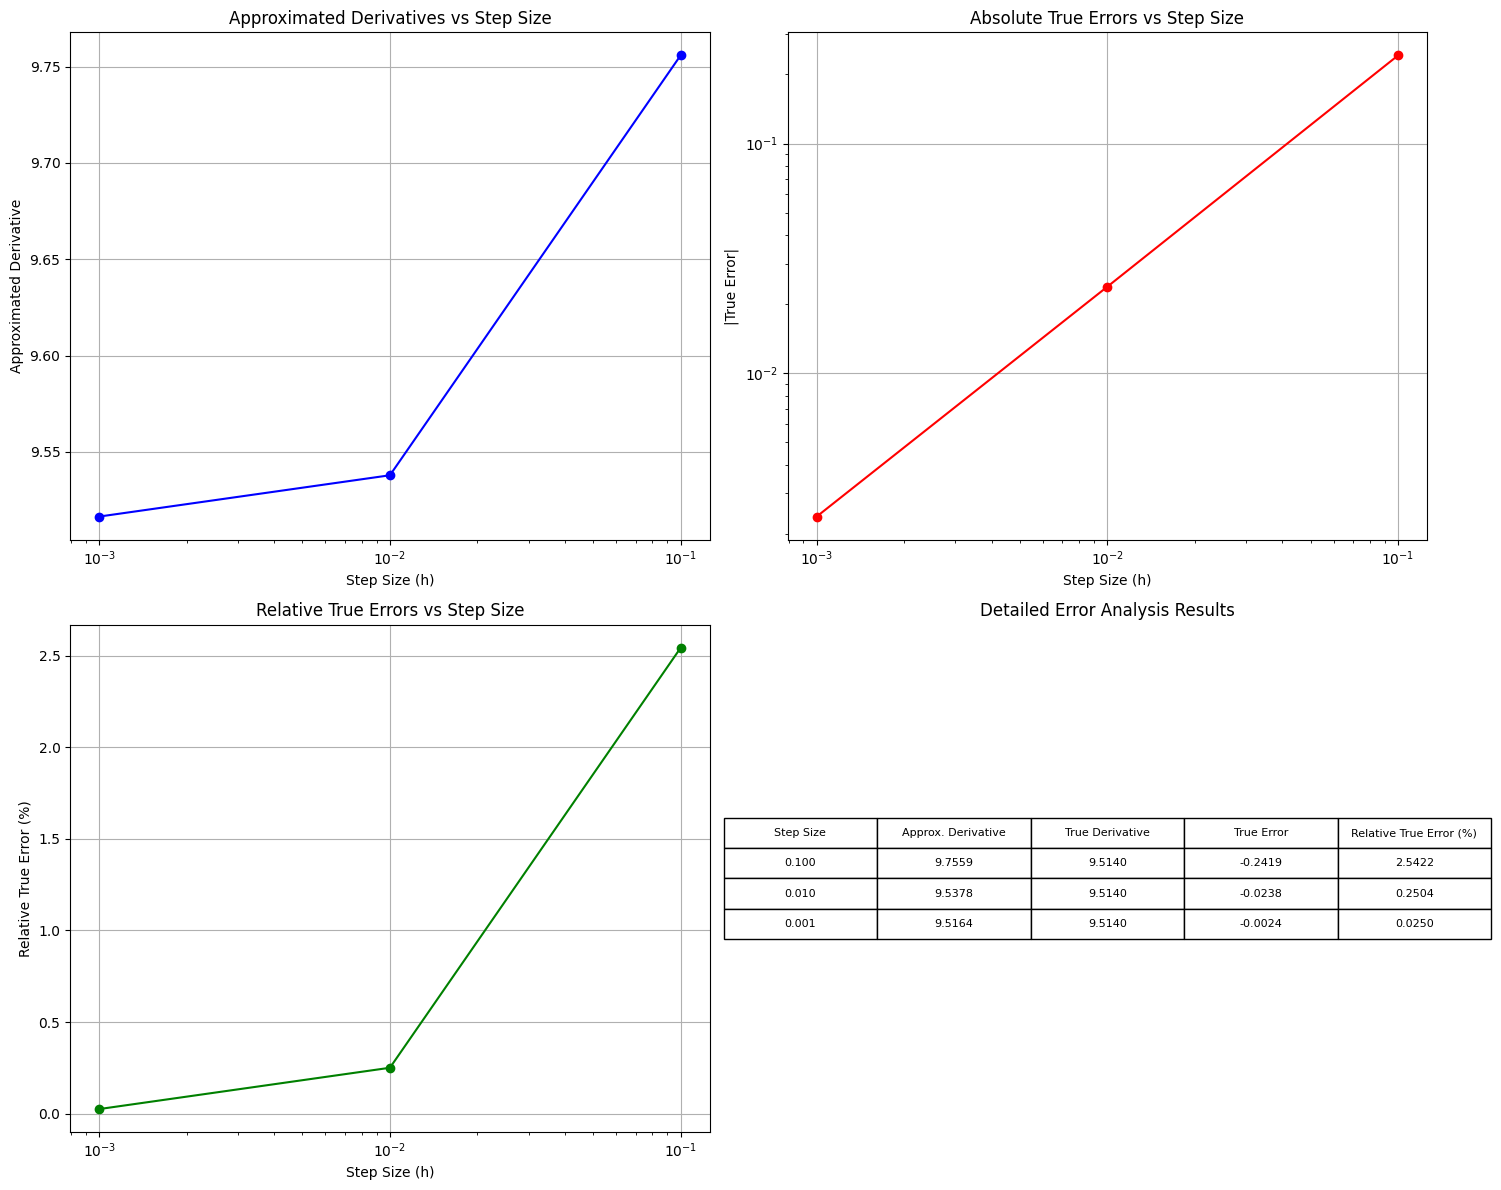


Error analysis completed successfully.


In [ ]:
if __name__ == "__main__":
    main()